In [1]:
import warnings

warnings.simplefilter("ignore")
#from altaipony.lcio import from_mast
#from funcs.detrend import custom_detrending, estimate_detrended_noise
import numpy as np
import pandas as pd 
from scipy.integrate import simps
from scipy.integrate import trapezoid
from prettytable import PrettyTable
from prettytable import from_csv
from prettytable import from_html

import matplotlib.pyplot as plt
from lightkurve import search_lightcurve 
import lightkurve as lk

In [2]:
search_result = search_lightcurve("AU Mic") 
lc2min = search_result[3].download() 
lc2 = lc2min.remove_nans().remove_outliers()
lc2 = lc2[lc2.quality == 0]
#lc2_m = lc2.remove_nans()
lc2_m = lc2.normalize().remove_nans()

In [3]:
x2min = np.ascontiguousarray(lc2_m.time.value, dtype=np.float64) 
y2min = np.ascontiguousarray(lc2_m.flux, dtype=np.float64)
yerr2min = np.ascontiguousarray(lc2_m.flux_err, dtype=np.float64)
lcquality = np.ascontiguousarray(lc2_m.quality, dtype=np.float64)

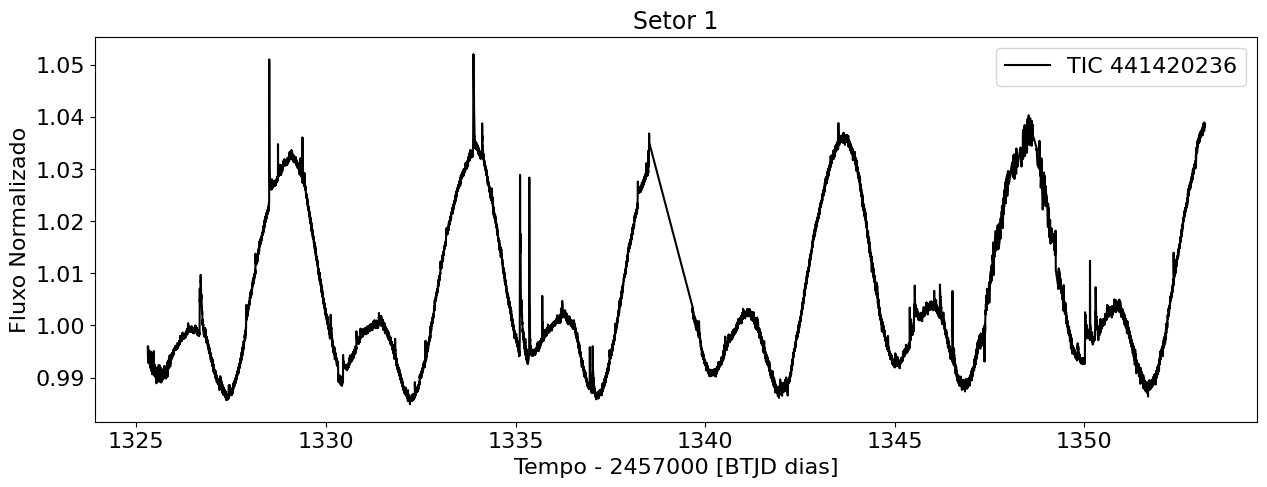

In [4]:
#%matplotlib notebook
plt.rcParams['font.size'] = '16' 
fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(x2min,y2min,'k')
labels= ["TIC 441420236"]
ax.set_xlabel('Tempo - 2457000 [BTJD dias]').set_fontsize(16)
ax.set_ylabel('Fluxo Normalizado').set_fontsize(16)  
plt.title('Setor 1').set_fontsize(17)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.legend(labels) 
plt.show()

In [ ]:
########### FLATTEN NOVO ##################

vetores = [
    [1326.6711, 1326.7794],
    [1327.8929, 1327.9763],
    [1328.4985, 1328.5822],
    [1328.4130, 1328,690],
    [1328.7326, 1328.7474],
    [1329.3756, 1329.4123],
    [1330.1210, 1330.1377],
    [1330.4496, 1330.5464],
    [1331.8210, 1331.8574],
    [1333.8797, 1333.9809],
    [1334.1134, 1334.1507],
    [1335.1052, 1335.2524],
    [1335.3517, 1335.4232],
    [1335.7022, 1335.7252],
    [1336.2287, 1336.2454],
    [1336.9519, 1336.9890],
    [1337.0179, 1337.0633],
    [1338.2201, 1338.2396],
    [1338.4973, 1338.5127],
    [1343.5045, 1343.5218],
    [1345.3914, 1345.4122],
    [1345.3918, 1345.4119],
    [1345.5044, 1345.5562],
    [1346.1841, 1346.2377],
    [1346.5162, 1346.5464],
    [1350.0068, 1350.0502],
    [1350.1441, 1350.3345],
    [1350.2795, 1350.3247],
    [1330.3039, 1330.4724],
    [1347.3173, 1347.3250],
    [1342.2240, 1342.2398],
    [1352.3514, 1352.3619],
    [1349.4516, 1349.4714],
    [1349.8142, 1349.8432],
    [1345.3926, 1345.4123],
    [1350.2720, 1350.3608],
    [1350.0112, 1350.4109],
    [1349.2727, 1349.3229],
]

vetor_true = [False]*len(x2min)


#indices = []
#indices = np.where((x2min>=vetores[0][0]) & (x2min<=vetores[0][1]))

for j in range(len(x2min)):
    for i in range(len(vetores)):
        if (x2min[j]>=vetores[i][0]) and (x2min[j]<=vetores[i][1]):
            vetor_true[j] = True

mascara = np.array(vetor_true)



flcd = lc2_m.flatten(window_length=350, polyorder=4, return_trend=False, break_tolerance=100, niters=3, sigma=2.5, mask=mascara)
x_detrend = np.ascontiguousarray(flcd.time.value, dtype=np.float64) 
y_detrend = np.ascontiguousarray(flcd.flux, dtype=np.float64)
#yerr_detrend= np.ascontiguousarray(flcd.flux_err, dtype=np.float64)

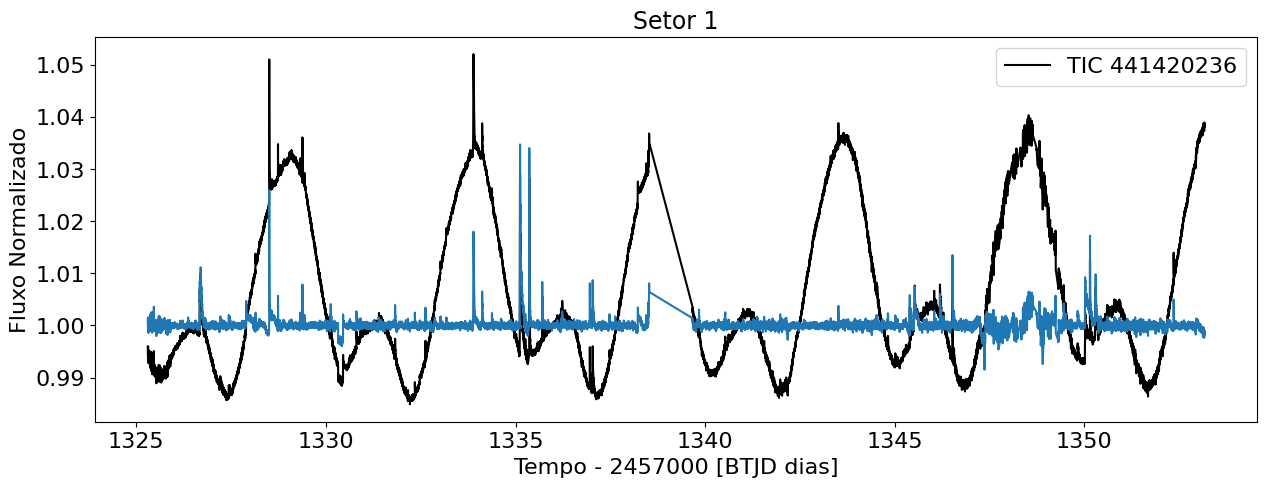

<Figure size 640x480 with 0 Axes>

In [6]:
plt.rcParams['font.size'] = '16' 
fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(x2min,y2min,'k')
plt.plot(x_detrend,y_detrend)
labels= ["TIC 441420236"]
ax.set_xlabel('Tempo - 2457000 [BTJD dias]').set_fontsize(16)
ax.set_ylabel('Fluxo Normalizado').set_fontsize(16)  
plt.title('Setor 1').set_fontsize(17)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.legend(labels) 
plt.show()
plt.savefig('ajuste_setor1.png', format='png')

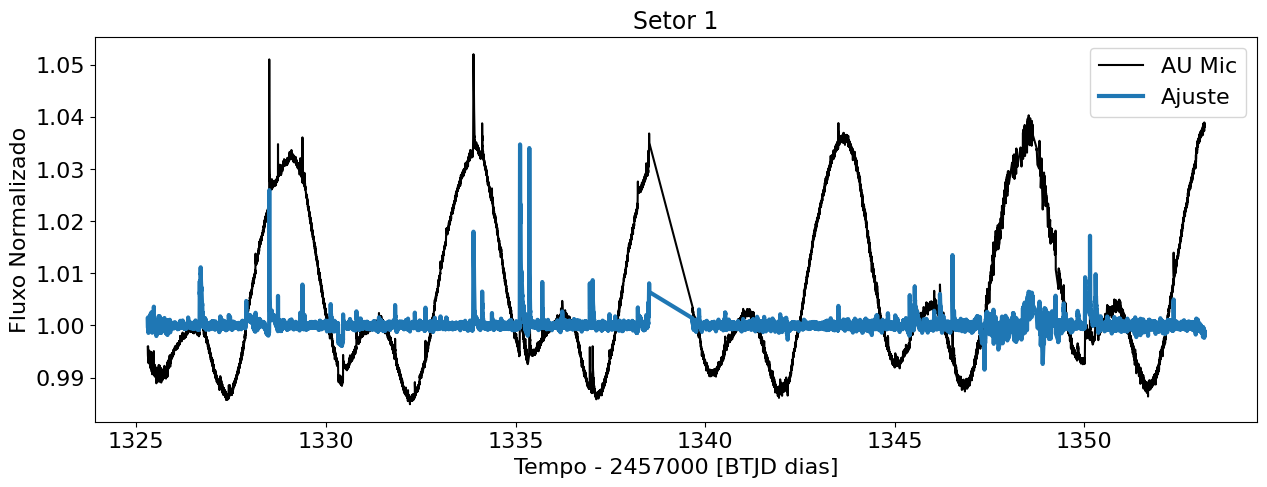

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(15, 5))
plt.plot(x2min, y2min, 'k', label='AU Mic')
plt.plot(x_detrend, y_detrend, linewidth=3, label="Ajuste")
plt.title('Setor 1', fontsize=17)
plt.ylabel("Fluxo Normalizado")
plt.xlabel("Tempo - 2457000 [BTJD dias]")
plt.legend()  # Adicione esta linha para mostrar as legendas
plt.show()  # Adicione esta linha para exibir o gráfico

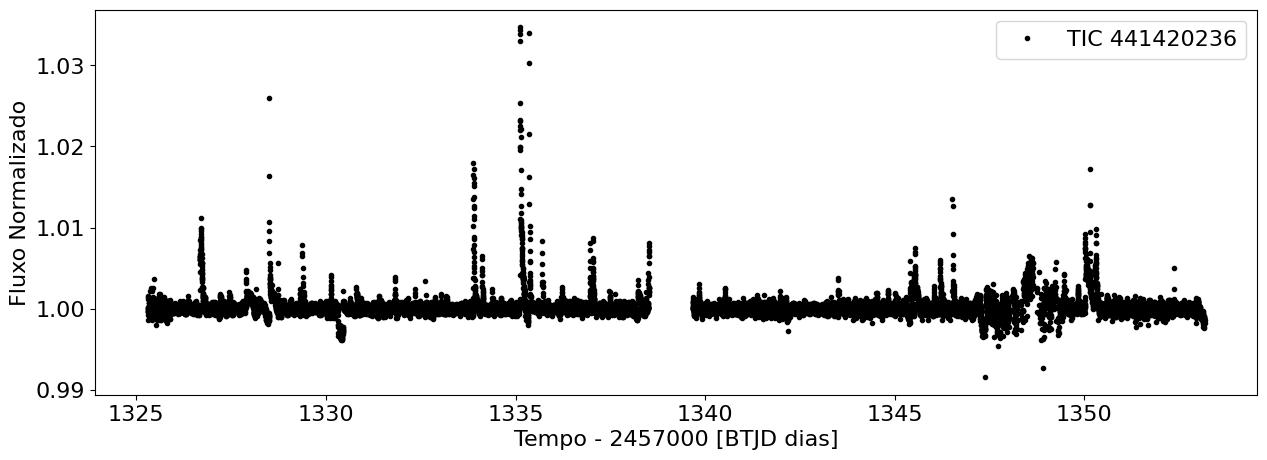

In [8]:


fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(x_detrend,y_detrend,'k.',label = 'TIC 441420236',)
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()

In [9]:
flcd.to_fits(path='lightcurve_s1.fits', overwrite=True)

In [10]:
#Transformando os arquivos em fits e salvando 
from astropy.io import fits
hdu = fits.open('lightcurve_s1.fits')
type(hdu)

astropy.io.fits.hdu.hdulist.HDUList

In [11]:
from astropy.table import Table
dat = Table.read('lightcurve_s1.fits', format='fits')
df = dat.to_pandas()

In [12]:
print(df.isna().sum()) #Contagem de dados nans nas colunas
df = df.dropna(subset=['TIME']) 
df = df.dropna(subset=['QUALITY']) # retirar valores 
print(df.isna().sum())
df.drop(df[df.QUALITY>0].index ,inplace=True) # exclui linhas onde flag com raios cósmicos

TIME          0
FLUX          0
FLUX_ERR      0
CADENCENO     0
MOM_CENTR1    0
MOM_CENTR2    0
QUALITY       0
dtype: int64
TIME          0
FLUX          0
FLUX_ERR      0
CADENCENO     0
MOM_CENTR1    0
MOM_CENTR2    0
QUALITY       0
dtype: int64


In [13]:
%matplotlib inline
time=df["TIME"] # tempo
flux=df["FLUX"] #flux
s=df["QUALITY"] # sap_quality
sf  = df['QUALITY'] > 1 # filtra flag com valores maiores que 1 ou seja flag 128 e 8192, são raios cósmicos
#from scipy.signal import savgol_filter
rf = np.mean(flux)/np.mean(flux) #Fluxo relativo

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


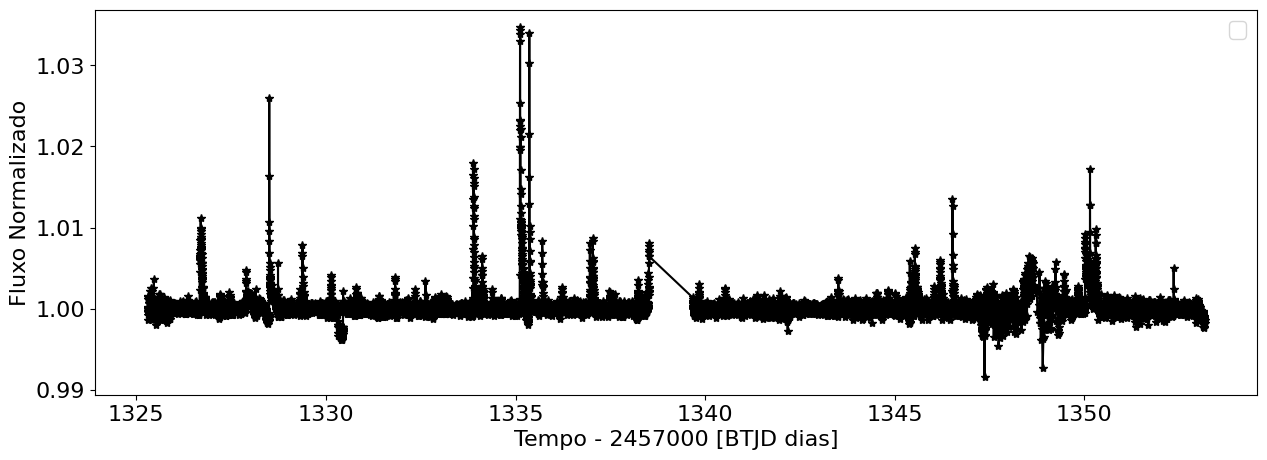

In [14]:

fig,ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(time,flux, 'k*-')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()

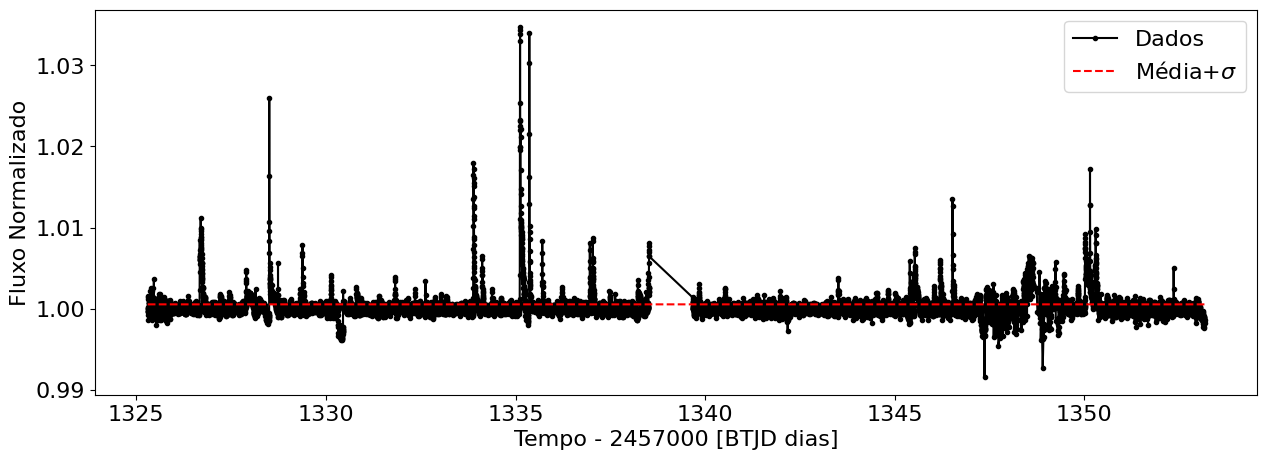

In [15]:
#%matplotlib notebook
#Calculando a média simples dos dados 
y_mean = [np.median(flux)]*len(time)

fig,ax = plt.subplots(1,1,figsize=(15,5))

data_line = ax.plot(time,flux, label='Dados', marker='.', color='black')

mean_line = ax.plot(time,y_mean+1/3*np.array(np.std(flux)), label='Média+$\sigma$', linestyle='--', color = 'red')
#mean_line = ax.plot(time,y_mean+np.std(flux), label='Mean+std', linestyle='--', color = 'red')

#Legenda
legend = ax.legend(loc='upper right')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()
plt.show()


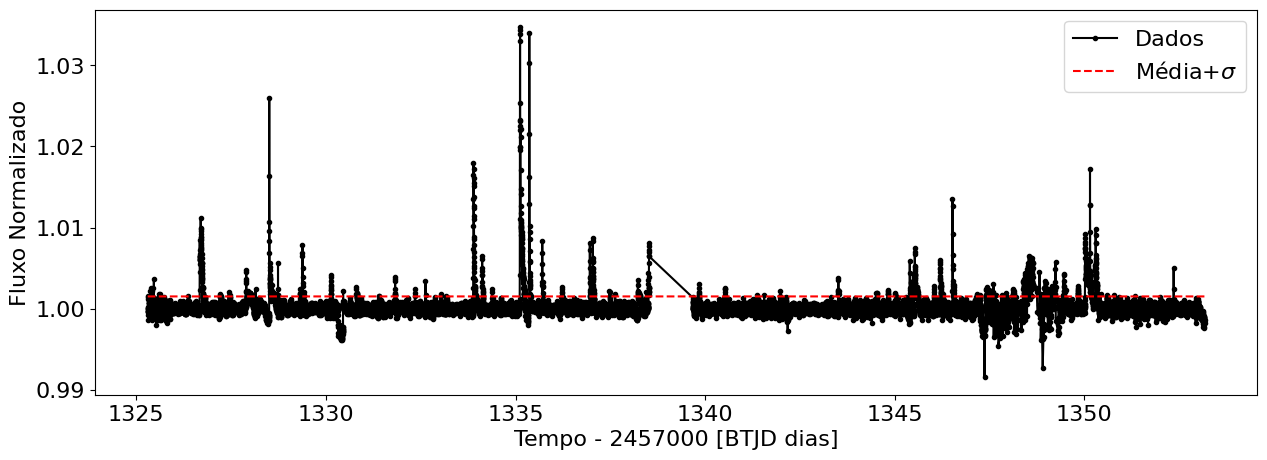

In [16]:
#%matplotlib notebook
#Calculando a média simples dos dados 
y_mean = [np.median(flux)]*len(time)

fig,ax = plt.subplots(1,1,figsize=(15,5))

data_line = ax.plot(time,flux, label='Dados', marker='.', color='black')

mean_line = ax.plot(time,y_mean+np.array(np.std(flux)), label='Média+$\sigma$', linestyle='--', color = 'red')
#mean_line = ax.plot(time,y_mean+np.std(flux), label='Mean+std', linestyle='--', color = 'red')

#Legenda
legend = ax.legend(loc='upper right')
ax.set(xlabel = 'Tempo - 2457000 [BTJD dias]', ylabel = 'Fluxo Normalizado',rasterized=True)
ax.legend()
plt.show()

In [17]:
##### Alguns dados básicos##################
fl129=pd.read_csv('flares_setor1.csv') #lendo os flares 
tess_f = pd.read_csv('tess_functionx1.csv') #lendo os arquivos da função de resposta
tf = pd.DataFrame(tess_f)
df = pd.DataFrame(fl129)

nm= np.array(tf["nm"]) # comprimento de onda em nm
ry= np.array(tf["ry"]) # tess function response

In [18]:
########## Constantes necessárias para o calculo da explosão#########

#Energia da flare
from PyAstronomy.pyasl import planck

#Mudança nm para cm e metro 
nm_metros = nm*(1e-9) #de nm para metros 
nm_cm = nm*(1e-7) #de nm para cm 


#Constantes importantes 
Teff= 3700# temperatura efetiva au mic
Tflare=10000# temperatura flare
raio=0.75*6.957e+10 # raio solar cm
sb1=5.67051e-5 #ergs cm-2*s-1*K-4


###########################
#Calculo da função de Planck
# Essa função (Bs=planck(Teff,lam=nm_metros)) da em [W/(m**2 m)] então
Bs=planck(Teff,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)
Bf=planck(Tflare,lam=nm_metros)*1e-7 #multiplicação de *1e-7 para converter erg/(cm**2*A*s)

In [19]:
######################## PARAMETROS DAS EXPLOSÕES #######################################
#Duração da flare

def dur(start,stop):
    dur1=abs(stop[0]-start[0])*1440
    #print("%.5f",dur1)
    #return dur1
    print("%.5f" %dur1)
    #dur1=abs(stop[1]-start[1])
    #print("diferença:", "%.5f" %dur1, "min", "inicio:", "%.5f" %start[1],"fim:", "%.5f" %stop[1], "")
    #print("inicio:", "%.5f" %start,"fim:", "%.5f" %stop, "min")
    
#Tempo de subida e descida
def subdes(start,stop):
    maximo = start[1]
    maximo_t = 0.0
    for i in range(len(time)):
        if time[i]>start[0] and time[i]<stop[0]:
            if flux[i]> maximo:
                maximo = flux[i]
                maximo_t = time[i]
    rise=(maximo_t-start[0])*1440
    decay=(stop[0]-maximo_t)*1440
    #print("Subida:", "%.5f" %rise, "min", "Descida:", "%.5f" %decay, "min")
    #print("%.5f" %decay)
    print("%.5f" %rise)
    #print("maximo", maximo)
    #print("inicio, fim", start[0],stop[0])
    #print("duração", (stop[0]-start[0])*1440)
    #print("duração2", (rise+decay))
    

def ampl(start,stop):
    maximo = start[1]
    minimo = start[1]
    med = np.mean(flux)
    for i in range(len(time)):
        if time[i]>start[0] and time[i]<stop[0]:
            if flux[i]> maximo:
                maximo = flux[i]
            if flux[i] < minimo:
                minimo = flux[i]  
    amplitude = maximo-minimo 
    print( "%.8f" %amplitude)
    
def flare(start,stop):
    flux_flare = []
    tempo_flare = []
    for i in range(len(time)):
        if time[i]>start[0] and time[i]<stop[0]:
            flux_flare.append(flux[i])
            tempo_flare.append(time[i])
            
    flux_flare = np.array(flux_flare)
    tempo_flare = np.array(tempo_flare)
    # Fluxo relativo da estrela (valor mínimo de fluxo na região da flare)
    f_rel_estrela = np.min(flux_flare)

    # Calcular a amplitude da flare (diferença entre o fluxo máximo da flare e o fluxo relativo da estrela)
    amplitude_flare =  flux_flare - 1
    # Integral
    Aflare = amplitude_flare*np.pi*(raio**2) #(cm^2)

    Aflare1 = simps(ry*Bs,nm_cm)/simps(ry*Bf,nm_cm)

    # Área total da flare
    Atotal = Aflare*Aflare1 #cm^2

    # Luminosidade da flare
    L = sb1*(Tflare**4)*Atotal #erg/s

    # Energia bolométrica do flare

    E1 = simps(L,tempo_flare*86400) #erg
    print('%.5e' %E1)


In [20]:
#Flares selecionadas
flare1_i = df.iloc[0,0],df.iloc[0,1]
flare1_f = df.iloc[0,2],df.iloc[0,3]
##########################
flare2_i = df.iloc[1,0],df.iloc[1,1]
flare2_f = df.iloc[1,2],df.iloc[1,3]
##########################
flare3_i = df.iloc[2,0],df.iloc[2,1]
flare3_f = df.iloc[2,2],df.iloc[2,3]
##########################
flare4_i = df.iloc[3,0],df.iloc[3,1]
flare4_f = df.iloc[3,2],df.iloc[3,3]
##########################
flare5_i = df.iloc[4,0],df.iloc[4,1]
flare5_f = df.iloc[4,2],df.iloc[4,3]
##########################
flare6_i = df.iloc[5,0],df.iloc[5,1]
flare6_f = df.iloc[5,2],df.iloc[5,3]
##########################
flare7_i = df.iloc[6,0],df.iloc[6,1]
flare7_f = df.iloc[6,2],df.iloc[6,3]
##########################
flare8_i = df.iloc[7,0],df.iloc[7,1]
flare8_f = df.iloc[7,2],df.iloc[7,3]
##########################
flare9_i = df.iloc[8,0],df.iloc[8,1]
flare9_f = df.iloc[8,2],df.iloc[8,3]
##########################
flare10_i = df.iloc[9,0],df.iloc[9,1]
flare10_f = df.iloc[9,2],df.iloc[9,3]
##########################
flare11_i = df.iloc[10,0],df.iloc[10,1]
flare11_f = df.iloc[10,2],df.iloc[10,3]
##########################
flare12_i = df.iloc[11,0],df.iloc[11,1]
flare12_f = df.iloc[11,2],df.iloc[11,3]
##########################
flare13_i = df.iloc[12,0],df.iloc[12,1]
flare13_f = df.iloc[12,2],df.iloc[12,3]
##########################
flare14_i = df.iloc[13,0],df.iloc[13,1]
flare14_f = df.iloc[13,2],df.iloc[13,3]
##########################
flare15_i = df.iloc[14,0],df.iloc[14,1]
flare15_f = df.iloc[14,2],df.iloc[14,3]
##########################
flare16_i = df.iloc[15,0],df.iloc[15,1]
flare16_f = df.iloc[15,2],df.iloc[15,3]
##########################
flare17_i = df.iloc[16,0],df.iloc[16,1]
flare17_f = df.iloc[16,2],df.iloc[16,3]
##########################
flare18_i = df.iloc[17,0],df.iloc[17,1]
flare18_f = df.iloc[17,2],df.iloc[17,3]
##########################
flare19_i = df.iloc[18,0],df.iloc[18,1]
flare19_f = df.iloc[18,2],df.iloc[18,3]
##########################
flare20_i = df.iloc[19,0],df.iloc[19,1]
flare20_f = df.iloc[19,2],df.iloc[19,3]
##########################
flare21_i = df.iloc[20,0],df.iloc[20,1]
flare21_f = df.iloc[20,2],df.iloc[20,3]
##########################
flare22_i = df.iloc[21,0],df.iloc[21,1]
flare22_f = df.iloc[21,2],df.iloc[21,3]
##########################
flare23_i = df.iloc[22,0],df.iloc[22,1]
flare23_f = df.iloc[22,2],df.iloc[22,3]
##########################
flare24_i = df.iloc[23,0],df.iloc[23,1]
flare24_f = df.iloc[23,2],df.iloc[23,3]
##########################
flare25_i = df.iloc[24,0],df.iloc[24,1]
flare25_f = df.iloc[24,2],df.iloc[24,3]
##########################
flare26_i = df.iloc[25,0],df.iloc[25,1]
flare26_f = df.iloc[25,2],df.iloc[25,3]
##########################
flare27_i = df.iloc[26,0],df.iloc[26,1]
flare27_f = df.iloc[26,2],df.iloc[26,3]
##########################
flare28_i = df.iloc[27,0],df.iloc[27,1]
flare28_f = df.iloc[27,2],df.iloc[27,3]
##########################
flare29_i = df.iloc[28,0],df.iloc[28,1]
flare29_f = df.iloc[28,2],df.iloc[28,3]
##########################
print(flare13_i,flare13_f,)

(1335.7001, 1.00031) (1335.7252, 0.99925)


In [21]:
flare(flare1_i,flare1_f) #Complexa
flare(flare2_i,flare2_f)
flare(flare3_i,flare3_f)
flare(flare4_i,flare4_f)
flare(flare5_i,flare5_f)
flare(flare6_i,flare6_f)
flare(flare7_i,flare7_f)
flare(flare8_i,flare8_f)
flare(flare9_i,flare9_f)
flare(flare10_i,flare10_f)
flare(flare11_i,flare11_f) #Complexa
flare(flare12_i,flare12_f)
flare(flare13_i,flare13_f)
flare(flare14_i,flare14_f)
flare(flare15_i,flare15_f)
flare(flare16_i,flare16_f) #Complexa
flare(flare17_i,flare17_f) #Complexa
flare(flare18_i,flare18_f)
flare(flare19_i,flare19_f) #Complexa
flare(flare20_i,flare20_f)
flare(flare21_i,flare21_f)
flare(flare22_i,flare22_f)
flare(flare23_i,flare23_f)
flare(flare24_i,flare24_f) #Complexa
flare(flare25_i,flare25_f) #Complexa
flare(flare26_i,flare26_f) #Complexa
flare(flare27_i,flare27_f)
flare(flare28_i,flare28_f) #Complexa
flare(flare29_i,flare29_f) 

7.19115e+33
1.03321e+33
2.58420e+33
3.03665e+32
9.35006e+32
7.13158e+32
7.98747e+32
4.74259e+32
5.83399e+33
1.15923e+33
1.52772e+34
3.78579e+33
8.81675e+32
2.71189e+32
1.11359e+33
2.33612e+33
1.51061e+33
4.51380e+32
4.04306e+32
3.57826e+32
3.80118e+33
1.67703e+33
1.36477e+33
7.56969e+33
1.87494e+33
3.17026e+33
2.48952e+32
5.06722e+32
6.44444e+32


In [22]:
dur(flare1_i,flare1_f)
dur(flare2_i,flare2_f)
dur(flare3_i,flare3_f)
dur(flare4_i,flare4_f)
dur(flare5_i,flare5_f)
dur(flare6_i,flare6_f)
dur(flare7_i,flare7_f)
dur(flare8_i,flare8_f)
dur(flare9_i,flare9_f)
dur(flare10_i,flare10_f)
dur(flare11_i,flare11_f)
dur(flare12_i,flare12_f)
dur(flare13_i,flare13_f)
dur(flare14_i,flare14_f)
dur(flare15_i,flare15_f)
dur(flare16_i,flare16_f)
dur(flare17_i,flare17_f)
dur(flare18_i,flare18_f)
dur(flare19_i,flare19_f)
dur(flare20_i,flare20_f)
dur(flare21_i,flare21_f)
dur(flare22_i,flare22_f)
dur(flare23_i,flare23_f)
dur(flare24_i,flare24_f)
dur(flare25_i,flare25_f)
dur(flare26_i,flare26_f)
dur(flare27_i,flare27_f)
dur(flare28_i,flare28_f)
dur(flare29_i,flare29_f)

201.02400
60.62400
49.68000
41.90400
42.62400
43.48800
73.72800
29.56320
121.68000
55.87200
212.68800
78.91200
36.14400
24.04800
53.42400
88.70400
114.04800
23.32800
24.91200
31.10400
150.33600
77.18400
43.48800
191.23200
30.67200
79.34400
20.30400
28.51200
41.76000


In [23]:
subdes(flare1_i,flare1_f)
subdes(flare2_i,flare2_f)
subdes(flare3_i,flare3_f)
subdes(flare4_i,flare4_f)
subdes(flare5_i,flare5_f)
subdes(flare6_i,flare6_f)
subdes(flare7_i,flare7_f)
subdes(flare8_i,flare8_f)
subdes(flare9_i,flare9_f)
subdes(flare10_i,flare10_f)
subdes(flare11_i,flare11_f)
subdes(flare12_i,flare12_f)
subdes(flare13_i,flare13_f)
subdes(flare14_i,flare14_f)
subdes(flare15_i,flare15_f)
subdes(flare16_i,flare16_f)
subdes(flare17_i,flare17_f)
subdes(flare18_i,flare18_f)
subdes(flare19_i,flare19_f)
subdes(flare20_i,flare20_f)
subdes(flare21_i,flare21_f)
subdes(flare22_i,flare22_f)
subdes(flare23_i,flare23_f)
subdes(flare24_i,flare24_f)
subdes(flare25_i,flare25_f)
subdes(flare26_i,flare26_f)
subdes(flare27_i,flare27_f)
subdes(flare28_i,flare28_f)
subdes(flare29_i,flare29_f)

47.13593
11.11547
4.12056
5.92738
5.84513
13.10583
12.24183
5.19127
15.48872
7.80487
18.45925
15.49474
5.79230
2.59809
9.17748
22.13622
4.64301
8.92557
11.23368
4.02109
31.29554
8.49926
6.26095
15.63661
4.63840
22.93523
2.30551
3.15150
10.98999


In [24]:
ampl(flare1_i,flare1_f)
ampl(flare2_i,flare2_f)
ampl(flare3_i,flare3_f)
ampl(flare4_i,flare4_f)
ampl(flare5_i,flare5_f)
ampl(flare6_i,flare6_f)
ampl(flare7_i,flare7_f)
ampl(flare8_i,flare8_f)
ampl(flare9_i,flare9_f)
ampl(flare10_i,flare10_f)
ampl(flare11_i,flare11_f)
ampl(flare12_i,flare12_f)
ampl(flare13_i,flare13_f)
ampl(flare14_i,flare14_f)
ampl(flare15_i,flare15_f)
ampl(flare16_i,flare16_f)
ampl(flare17_i,flare17_f)
ampl(flare18_i,flare18_f)
ampl(flare19_i,flare19_f)
ampl(flare20_i,flare20_f)
ampl(flare21_i,flare21_f)
ampl(flare22_i,flare22_f)
ampl(flare23_i,flare23_f)
ampl(flare24_i,flare24_f)
ampl(flare25_i,flare25_f)
ampl(flare26_i,flare26_f)
ampl(flare27_i,flare27_f)
ampl(flare28_i,flare28_f)
ampl(flare29_i,flare29_f)

0.01271970
0.00470650
0.02653736
0.00634472
0.00915148
0.00447652
0.00552652
0.00456127
0.01762605
0.00760465
0.03629434
0.03550150
0.00829601
0.00314365
0.00952288
0.01129560
0.00421589
0.00541244
0.00470358
0.00744271
0.00797505
0.00681555
0.01529783
0.00975744
0.01838381
0.00924976
0.00573700
0.00506241
0.00303619


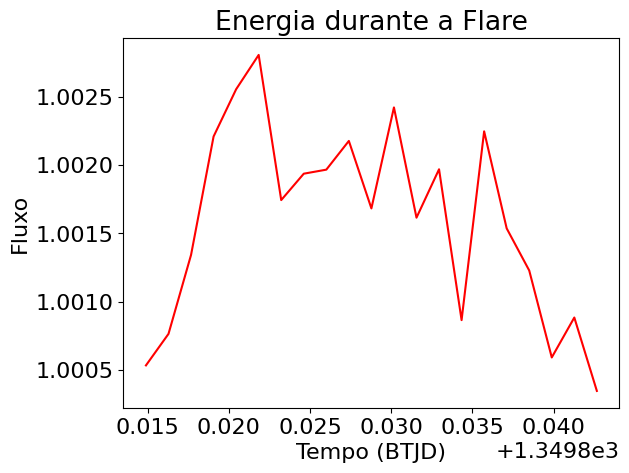

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Valores de início e término da flare (substitua pelos valores desejados)
start_input =1349.8142



















stop_input =1349.8432























def ener_flare(start, stop, time, flux):
    flux_flare = []
    tempo_flare = []
    for i in range(len(time)):
        if time[i] >= start and time[i] <= stop:
            flux_flare.append(flux[i])
            tempo_flare.append(time[i])

    flux_flare = np.array(flux_flare)
    tempo_flare = np.array(tempo_flare)
    
    return flux_flare, tempo_flare

# Chamada da função ener_flare com os dados de exemplo
flux_flare, tempo_flare = ener_flare(start_input, stop_input, time, flux)
# Criação do gráfico do tempo_flare em relação ao fluxo_flare
plt.plot(tempo_flare, flux_flare, 'r')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()

6.444441281582555e+32


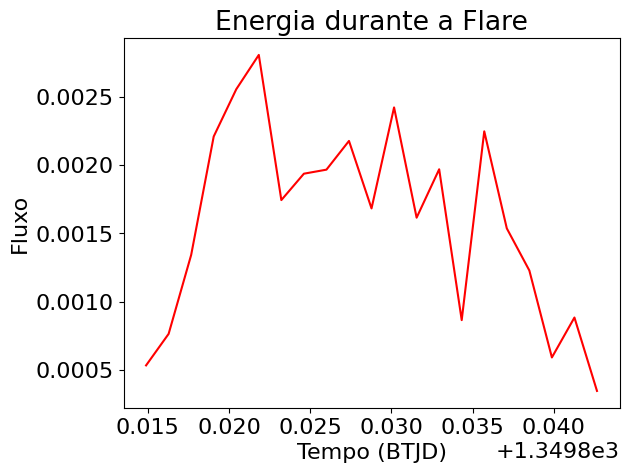

In [26]:
flux_flare1 = np.array(flux_flare)
tempo_flare1 = np.array(tempo_flare) 

# Fluxo relativo da estrela (valor mínimo de fluxo na região da flare)
f_rel_estrela = np.min(flux_flare1)

# Calcular a amplitude da flare (diferença entre o fluxo máximo da flare e o fluxo relativo da estrela)
amplitude_flare =  flux_flare1 - 1


# Integral
Aflare = amplitude_flare*np.pi*(raio**2) #(cm^2)

Aflare1 = simps(ry*Bs,nm_cm)/simps(ry*Bf,nm_cm)

# Área total da flare
Atotal = Aflare*Aflare1 #cm^2

# Luminosidade da flare
L = sb1*(Tflare**4)*Atotal #erg/s

# Energia bolométrica do flare

E1 = simps(L,tempo_flare1*86400) #erg



print(E1)

# Criação do gráfico do tempo_flare em relação ao fluxo_flare
plt.plot(tempo_flare1, amplitude_flare, 'r-')
plt.xlabel('Tempo (BTJD)')
plt.ylabel('Fluxo')
plt.title('Energia durante a Flare')
plt.show()